# L5.2 — Embeddings

Hands-on notebook for the lesson [`5-2-embedding.mdx`](../../llm-quest-theory/level-5/5-2-embedding.mdx).

> **Learning objectives**
> - Encode real sentences with `sentence-transformers/all-MiniLM-L6-v2` and inspect the output shape.
> - Cluster them in 2-D via PCA and t-SNE and see "meaning" become geometry.
> - Run top-k nearest-neighbor retrieval via cosine similarity — a one-cell mini RAG engine.
> - See the limits of modern sentence embeddings on the classic `king - man + woman = queen` analogy.

## Connection to the theory
Covers **§1–§10** of the source `.mdx`. The geometry you observe here is exactly what RAG systems rely on in Level 6.

In [1]:
# ---- Setup ----
import os, warnings
warnings.filterwarnings("ignore", category=FutureWarning)
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
os.environ["TOKENIZERS_PARALLELISM"] = "false"
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["figure.dpi"] = 100
%matplotlib inline

## 1. One-hot vs a dense embedding
One-hot vectors are orthogonal — every pair has cosine similarity 0. Embeddings let us encode "meaning" as distance.

In [2]:
vocab = ["cat", "dog", "bank (river)", "bank (money)", "paris", "tokyo"]
V = len(vocab)
one_hot = np.eye(V)
def cos(u, v):
    return float(np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v) + 1e-12))
for i in range(V):
    for j in range(i + 1, V):
        print(f"  cos({vocab[i]}, {vocab[j]}) = {cos(one_hot[i], one_hot[j]):.1f}")

  cos(cat, dog) = 0.0
  cos(cat, bank (river)) = 0.0
  cos(cat, bank (money)) = 0.0
  cos(cat, paris) = 0.0
  cos(cat, tokyo) = 0.0
  cos(dog, bank (river)) = 0.0
  cos(dog, bank (money)) = 0.0
  cos(dog, paris) = 0.0
  cos(dog, tokyo) = 0.0
  cos(bank (river), bank (money)) = 0.0
  cos(bank (river), paris) = 0.0
  cos(bank (river), tokyo) = 0.0
  cos(bank (money), paris) = 0.0
  cos(bank (money), tokyo) = 0.0
  cos(paris, tokyo) = 0.0


## 2. Real sentence embeddings via MiniLM
The first run downloads the model (~90 MB). It produces a 384-D vector per sentence.

In [3]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
print("embedding dim:", model.get_sentence_embedding_dimension())

embedding dim: 384


In [4]:
sentences = [
    # animals
    "The cat sleeps on the sofa.",
    "A kitten is purring on the couch.",
    "Dogs are loyal companions.",
    "Puppies love to chase their tails.",
    # cities
    "Paris is the capital of France.",
    "Tokyo is the largest city in Japan.",
    "Berlin is the capital of Germany.",
    "London sits on the river Thames.",
    # programming
    "Python is a popular programming language.",
    "I wrote a Python script to parse JSON.",
    "Rust is known for memory safety.",
    "The compiler rejected my TypeScript code.",
    # food
    "The pizza has extra cheese.",
    "I ordered sushi for dinner.",
    "She baked chocolate chip cookies.",
    "The chef prepared a vegetable stir-fry.",
]
labels = ["animals"] * 4 + ["cities"] * 4 + ["programming"] * 4 + ["food"] * 4

embs = model.encode(sentences, convert_to_numpy=True, normalize_embeddings=True)
print("embeddings shape:", embs.shape, "(one 384-D vector per sentence)")

embeddings shape: (16, 384) (one 384-D vector per sentence)


## 3. 2-D projection: PCA vs t-SNE
PCA is the linear shadow. t-SNE preserves neighborhood structure better but is non-linear and stochastic.

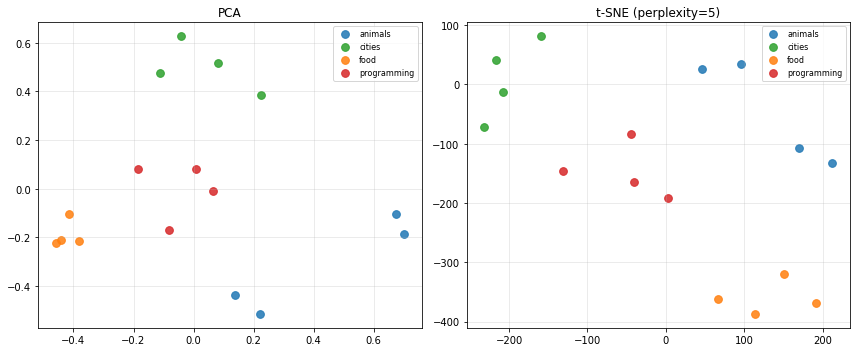

In [5]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

pca_2d  = PCA(n_components=2, random_state=SEED).fit_transform(embs)
tsne_2d = TSNE(n_components=2, perplexity=5, random_state=SEED, init="pca").fit_transform(embs)

def scatter(ax, coords, title):
    colors = {"animals": "tab:blue", "cities": "tab:green",
              "programming": "tab:red", "food": "tab:orange"}
    for lbl in sorted(set(labels)):
        mask = [l == lbl for l in labels]
        ax.scatter(coords[mask, 0], coords[mask, 1], c=colors[lbl], label=lbl, s=60, alpha=0.85)
    ax.grid(alpha=0.3); ax.legend(fontsize=8); ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
scatter(axes[0], pca_2d,  "PCA")
scatter(axes[1], tsne_2d, "t-SNE (perplexity=5)")
plt.tight_layout(); plt.show()

## 4. Top-k nearest neighbors = mini semantic search
One query vector + cosine similarity + `argsort` is a full retrieval engine in four lines.

In [6]:
def top_k(query, corpus_embs, corpus_texts, k=3):
    q = model.encode([query], convert_to_numpy=True, normalize_embeddings=True)[0]
    sims = corpus_embs @ q                    # corpus is pre-normalised -> dot product = cos
    idx  = np.argsort(-sims)[:k]
    return [(corpus_texts[i], float(sims[i])) for i in idx]

for q in ["a programming language with memory safety",
         "cute animals and pets",
         "a meal with cheese and tomato",
         "European capitals"]:
    print(f"\nquery: {q!r}")
    for text, s in top_k(q, embs, sentences, k=3):
        print(f"  {s:.3f}  {text}")


query: 'a programming language with memory safety'
  0.551  Rust is known for memory safety.
  0.410  Python is a popular programming language.
  0.182  The compiler rejected my TypeScript code.

query: 'cute animals and pets'
  0.456  Dogs are loyal companions.
  0.437  Puppies love to chase their tails.
  0.242  A kitten is purring on the couch.

query: 'a meal with cheese and tomato'
  0.611  The pizza has extra cheese.
  0.384  I ordered sushi for dinner.
  0.357  The chef prepared a vegetable stir-fry.

query: 'European capitals'
  0.533  Berlin is the capital of Germany.
  0.519  Paris is the capital of France.
  0.196  Tokyo is the largest city in Japan.


## 5. Word analogies — do sentence embeddings still do algebra?
Classic `king - man + woman ≈ queen` test, generalised to short phrases. Modern sentence embeddings are *not* tuned for this — they cluster *meaning*, not word relations. See how well (or badly) it works.

In [7]:
candidates = ["king", "queen", "prince", "princess",
              "man", "woman", "boy", "girl",
              "france", "paris", "japan", "tokyo",
              "italy", "rome", "germany", "berlin"]
cand_embs = model.encode(candidates, convert_to_numpy=True, normalize_embeddings=True)

def analogy(a, b, c, k=3):
    # a is to b as c is to ?
    a_v, b_v, c_v = model.encode([a, b, c], convert_to_numpy=True, normalize_embeddings=True)
    target = b_v - a_v + c_v
    target = target / (np.linalg.norm(target) + 1e-12)
    sims = cand_embs @ target
    # Filter out the input words
    ranked = sorted(range(len(candidates)), key=lambda i: -sims[i])
    ranked = [i for i in ranked if candidates[i] not in {a, b, c}]
    return [(candidates[i], float(sims[i])) for i in ranked[:k]]

for a, b, c, expected in [
    ("man", "king", "woman", "queen"),
    ("boy", "prince", "girl", "princess"),
    ("france", "paris", "japan", "tokyo"),
    ("italy", "rome", "germany", "berlin"),
]:
    hits = analogy(a, b, c, k=3)
    got = hits[0][0]
    mark = "✓" if got == expected else "✗"
    print(f"{mark}  {a} : {b} :: {c} : {got:<10}  (expected {expected})    top-3 = {[h[0] for h in hits]}")

✓  man : king :: woman : queen       (expected queen)    top-3 = ['queen', 'princess', 'prince']
✓  boy : prince :: girl : princess    (expected princess)    top-3 = ['princess', 'queen', 'woman']
✓  france : paris :: japan : tokyo       (expected tokyo)    top-3 = ['tokyo', 'berlin', 'rome']
✓  italy : rome :: germany : berlin      (expected berlin)    top-3 = ['berlin', 'paris', 'france']


Don't be surprised if some analogies miss — MiniLM was trained for *sentence similarity*, not word algebra. Word2vec-style analogies work better on word-level models. This is an honest limitation to know about.

## 6. Contextual meaning — "bank" disambiguated
Sentence embedding shifts when the same word sits in a different context — proof that these are contextual, unlike classic word2vec.

In [8]:
bank_sents = [
    "We sat by the river bank watching the sunset.",
    "A small boat was tied to the muddy river bank.",
    "I deposited money at the bank this morning.",
    "The bank approved my mortgage application.",
]
bank_embs = model.encode(bank_sents, convert_to_numpy=True, normalize_embeddings=True)

import pandas as pd
cos = bank_embs @ bank_embs.T
print("cosine-similarity matrix (rows/cols = sentence indices):")
print(np.round(cos, 3))

# Two 'river bank' sentences should be closer to each other than to the money ones
river_pair = cos[0, 1]
money_pair = cos[2, 3]
cross      = cos[0, 2]
print(f"\nriver-river similarity : {river_pair:.3f}")
print(f"money-money similarity : {money_pair:.3f}")
print(f"cross-sense similarity : {cross:.3f}")

cosine-similarity matrix (rows/cols = sentence indices):
[[1.    0.332 0.286 0.192]
 [0.332 1.    0.258 0.139]
 [0.286 0.258 1.    0.413]
 [0.192 0.139 0.413 1.   ]]

river-river similarity : 0.332
money-money similarity : 0.413
cross-sense similarity : 0.286


## 7. Quick checks

In [9]:
# Embedding shapes are right
assert embs.shape == (16, 384)
assert np.allclose(np.linalg.norm(embs, axis=1), 1.0, atol=1e-5), "normalize_embeddings should unit-normalise"
# Top-k retrieval returns items from the right category more often than not
top = top_k("European capitals", embs, sentences, k=3)
assert sum("Paris" in t or "Berlin" in t or "London" in t for t, _ in top) >= 2
# Same-sense pairs must be closer than cross-sense pairs for 'bank'
assert river_pair > cross and money_pair > cross, "contextual embedding should separate the two senses"
print("OK — MiniLM embeds, retrieves, and disambiguates sense as expected.")

OK — MiniLM embeds, retrieves, and disambiguates sense as expected.


## Reflection questions

1. Embedding dimensions are almost always multiples of 64 (384, 512, 768, 4096). What hardware reason drives that?
2. Why does PCA smush the four categories in section 3 while t-SNE separates them better?
3. If you pass GPT-2's token embeddings through mean-pooling to build a sentence vector, would it rival MiniLM for retrieval? Why / why not?
4. For a RAG system with 1 million docs, what is the cost difference between computing cosine sim via `embs @ q` every query vs. using an ANN index like FAISS? (We'll use FAISS in lesson 6-3.)

## References
- Source theory: [`5-2-embedding.mdx`](../../llm-quest-theory/level-5/5-2-embedding.mdx)
- Next: [`5-3-pretraining`](5-3-pretraining.ipynb)